# Online Shopping Behavior – Exploratory Data Analysis

**Dataset:** Online Shopping (588 records, 9 features)  
**Goal:** Clean the data, explore patterns, and extract actionable insights about customer behavior.

| Team Member | Role |
|------------|------|
| Zaid | Data Cleaning & Preprocessing |
| Jana | Univariate Analysis |
| Manar | Bivariate Analysis |
| All Members | Data Understanding & Conclusions |


## Setup – Import Libraries

In [516]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries loaded successfully")


Libraries loaded successfully


---
## Step 1: Data Understanding

In this step, we examine the structure, features, and overall characteristics of the dataset
to understand what we are working with before performing any cleaning or analysis.


In [517]:
# Load the original dataset
df_original = pd.read_csv('../data/online_shopping.csv')
print('Data has been read from the file successfully')

print(f'\nDataset size:')
print(f'  Number of rows   : {df_original.shape[0]}')
print(f'  Number of columns: {df_original.shape[1]}')


Data has been read from the file successfully

Dataset size:
  Number of rows   : 588
  Number of columns: 9


In [518]:
# Preview the first 10 rows
print("First 10 rows of the dataset:")
df_original.head(10)


First 10 rows of the dataset:


,age,gender,time_on_site,pages_viewed,device,purchase_amount,discount_used,click_rate,return_customer
0,63.0,Male,18.685621,3,mobile,289.253886,Yes,35.878814,1.0
1,43.0,Female,4.411306,9,Desktop,224.366091,No,177.625321,0.0
2,35.0,Male,9.217575,17,Mobile,254.559993,Yes,42.648411,0.0
3,NaN,Female,13.183255,4,Desktop,66.949884,No,34.546995,1.0
4,NaN,Female,17.709027,3,mobile,170.062225,Yes,56.095720,0.0
5,59.0,Male,13.923434,15,mobile,292.988001,No,48.740125,0.0
6,45.0,Male,7.349641,7,mobile,167.358900,Yes,47.675041,0.0
7,51.0,Female,13.322453,12,NaN,21.820469,Yes,165.859939,0.0
8,55.0,Male,16.389287,15,Desktop,280.710393,Yes,135.236273,1.0
9,21.0,Female,12.459039,16,mobile,85.398233,No,159.539694,0.0


In [519]:
# Column data types and non-null counts
print("Dataset info:")
df_original.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588 entries, 0 to 587
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              544 non-null    float64
 1   gender           560 non-null    object 
 2   time_on_site     540 non-null    float64
 3   pages_viewed     582 non-null    object 
 4   device           545 non-null    object 
 5   purchase_amount  586 non-null    float64
 6   discount_used    583 non-null    object 
 7   click_rate       583 non-null    float64
 8   return_customer  560 non-null    float64
dtypes: float64(5), object(4)
memory usage: 41.5+ KB


In [520]:
# Missing values analysis
print('Missing values analysis:')
missing_count   = df_original.isnull().sum()
missing_percent = (missing_count / len(df_original) * 100).round(2)
missing_df = pd.DataFrame({
    'Column'        : df_original.columns,
    'Missing Count' : missing_count.values,
    'Percentage (%)': missing_percent.values
})
print(missing_df.to_string(index=False))


Missing values analysis:
         Column  Missing Count  Percentage (%)
            age             44            7.48
         gender             28            4.76
   time_on_site             48            8.16
   pages_viewed              6            1.02
         device             43            7.31
purchase_amount              2            0.34
  discount_used              5            0.85
     click_rate              5            0.85
return_customer             28            4.76


In [521]:
# Summary statistics for all columns
print('Dataset summary statistics:')
df_original.describe().round(2)


Dataset summary statistics:


,age,time_on_site,purchase_amount,click_rate,return_customer
count,544.00,540.00,586.00,583.00,560.00
mean,41.45,9.78,153.13,100.17,0.54
std,13.20,5.28,86.51,58.90,0.50
min,18.00,-4.59,10.05,-57.31,0.00
25%,30.75,6.06,71.87,58.59,0.00
50%,41.50,9.51,158.24,101.15,1.00
75%,53.00,13.16,225.78,141.78,1.00
max,64.00,26.85,299.31,323.26,1.00


---
## Step 2: Data Cleaning and Preprocessing

**Responsible:** Zaid

In this section we prepare a clean, analysis-ready version of the dataset by:
1. Handling missing values  
2. Correcting data types  
3. Standardising categorical labels  
4. Detecting and fixing anomalies (negative values)  
5. Smoothing noisy data with IQR-based capping  
6. Identifying and treating outliers  
7. Removing duplicate rows  


### 2.1 Handling Missing Values

We first convert invalid entries (e.g., `'many'` in `pages_viewed`) into NaN,
then fill numerical columns with the **median** and categorical columns with the **mode**.


In [522]:
# Create a working copy of the original dataset
df_clean = df_original.copy()

# Convert columns that should be numeric but may contain text
df_clean['pages_viewed']   = pd.to_numeric(df_clean['pages_viewed'],   errors='coerce')
df_clean['return_customer'] = pd.to_numeric(df_clean['return_customer'], errors='coerce')

missing_before = int(df_clean.isnull().sum().sum())

# Fill missing numerical values with the median 
num_cols = ['age', 'time_on_site', 'pages_viewed', 'purchase_amount',
            'click_rate', 'return_customer']
for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with the mode
cat_cols = ['gender', 'device', 'discount_used']
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

missing_after = int(df_clean.isnull().sum().sum())
print(f"Missing values before cleaning : {missing_before}")
print(f"Missing values after  cleaning : {missing_after}")


Missing values before cleaning : 239
Missing values after  cleaning : 0


### 2.2 Data Type Correction

After filling missing values, we convert the numeric fields to the correct types for analysis.

In [523]:
# Convert float-based numeric columns to integers where appropriate
df_clean['pages_viewed']   = df_clean['pages_viewed'].round().astype(int)
df_clean['return_customer'] = df_clean['return_customer'].round().astype(int)

print('Data types after correction:')
print(df_clean.dtypes)


Data types after correction:
age                float64
gender              object
time_on_site       float64
pages_viewed         int64
device              object
purchase_amount    float64
discount_used       object
click_rate         float64
return_customer      int64
dtype: object


### 2.3 Categorical Standardisation

Fixing naming inconsistencies (e.g., `'mobile'` vs `'Mobile'`) to ensure uniform labels.

In [524]:
# Standardise text formatting in categorical columns
df_clean['device']        = df_clean['device'].str.strip().str.capitalize()
df_clean['gender']        = df_clean['gender'].str.strip().str.capitalize()
df_clean['discount_used'] = df_clean['discount_used'].str.strip().str.capitalize()

print("Device categories after standardisation:")
print(df_clean['device'].value_counts())
print("\nGender categories after standardisation:")
print(df_clean['gender'].value_counts())


Device categories after standardisation:
device
Mobile     409
Desktop    179
Name: count, dtype: int64

Gender categories after standardisation:
gender
Male      343
Female    245
Name: count, dtype: int64


### 2.4 Anomaly Detection and Treatment

Fixing logical errors such as negative values in `time_on_site` and `click_rate`.

In [525]:
# Count and replace negative values with the median of valid records
for col in ['time_on_site', 'click_rate']:
    neg_count = int((df_clean[col] < 0).sum())
    valid_median = df_clean.loc[df_clean[col] >= 0, col].median()
    df_clean.loc[df_clean[col] < 0, col] = valid_median
    print(f"Negative '{col}' values fixed: {neg_count}  (replaced with median = {valid_median:.2f})")


Negative 'time_on_site' values fixed: 16  (replaced with median = 9.51)
Negative 'click_rate' values fixed: 26  (replaced with median = 103.60)


### 2.5 Noisy Data – Outlier Smoothing (IQR Capping)

We apply **IQR-based Winsorisation** (capping) to `click_rate` and `time_on_site`,
which showed extreme upper values in the boxplots.  
Values below Q1 − 1.5·IQR or above Q3 + 1.5·IQR are capped to the fence values.
This smooths the noise while keeping all rows.


In [526]:
def iqr_cap(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

    lower = max(lower, 0)

    
    n_outliers = ((series < lower) | (series > upper)).sum()

    capped = series.clip(lower=lower, upper=upper)

    return capped, n_outliers, lower, upper

for col in ['click_rate', 'time_on_site']:
    df_clean[col], n_out, lo, hi = iqr_cap(df_clean[col])
    print(f"[{col}]  outliers capped: {n_out}  |  fence: [{lo:.2f}, {hi:.2f}]")



print("\nOutlier smoothing complete.")


[click_rate]  outliers capped: 3  |  fence: [0.00, 249.70]
[time_on_site]  outliers capped: 6  |  fence: [0.00, 21.38]

Outlier smoothing complete.


### 2.6 Removing Duplicates and Final Validation

In [527]:
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()

validation_summary = pd.DataFrame({
    'Check': [
        'Remaining missing values',
        'Remaining duplicate rows',
        'Negative time_on_site values',
        'Negative click_rate values',
    ],
    'Value': [
        int(df_clean.isnull().sum().sum()),
        int(df_clean.duplicated().sum()),
        int((df_clean['time_on_site'] < 0).sum()),
        int((df_clean['click_rate']   < 0).sum()),
    ]
})

print(f"Removed {initial_rows - df_clean.shape[0]} duplicate rows.")
print(f"Final cleaned dataset shape: {df_clean.shape}")
print()
print(validation_summary.to_string(index=False))


Removed 21 duplicate rows.
Final cleaned dataset shape: (567, 9)

                       Check  Value
    Remaining missing values      0
    Remaining duplicate rows      0
Negative time_on_site values      0
  Negative click_rate values      0


### 2.7 Exporting Cleaned Data

In [528]:
df_clean.to_csv('../data/online_shopping_cleaned.csv', index=False)
print("Cleaned dataset saved as 'online_shopping_cleaned.csv'")
df_clean.head()


Cleaned dataset saved as 'online_shopping_cleaned.csv'


,age,gender,time_on_site,pages_viewed,device,purchase_amount,discount_used,click_rate,return_customer
0,63.0,Male,18.685621,3,Mobile,289.253886,Yes,35.878814,1
1,43.0,Female,4.411306,9,Desktop,224.366091,No,177.625321,0
2,35.0,Male,9.217575,17,Mobile,254.559993,Yes,42.648411,0
3,41.5,Female,13.183255,4,Desktop,66.949884,No,34.546995,1
4,41.5,Female,17.709027,3,Mobile,170.062225,Yes,56.095720,0


---
## Step 3: Univariate Analysis

**Responsible:** Jana

We examine each feature individually to understand its distribution, central tendency, and spread.


### 3.1 Summary Statistics for Numerical Features

In [529]:
num_features = ['age', 'time_on_site', 'pages_viewed',
                'purchase_amount', 'click_rate']
df_clean[num_features].describe().round(2)


,age,time_on_site,pages_viewed,purchase_amount,click_rate
count,567.00,567.00,567.00,567.00,567.00
mean,41.47,9.99,9.90,152.93,105.59
std,12.67,4.56,5.17,86.30,51.04
min,18.00,0.15,1.00,10.05,1.59
25%,32.00,7.16,6.00,72.01,69.25
50%,41.50,9.51,10.00,158.24,103.60
75%,52.00,12.59,14.00,224.94,141.13
max,64.00,21.38,19.00,299.31,249.70


### 3.2 Distribution of Purchase Amount

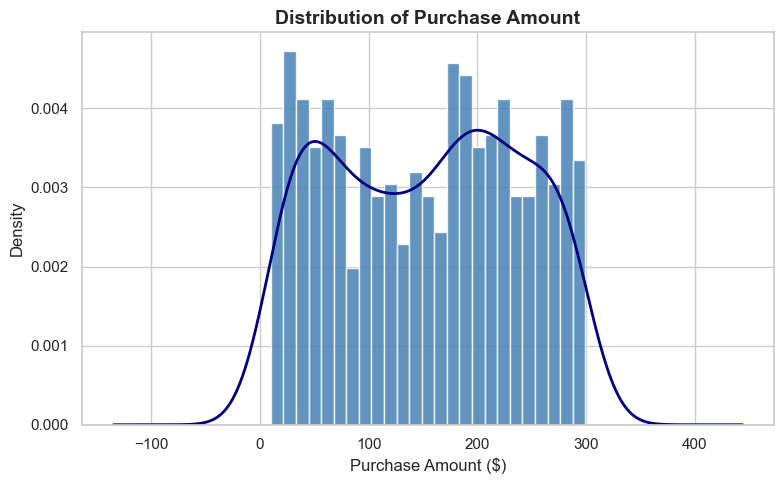

Observation: Purchase amount follows an approximately uniform distribution
between $10 and $300. There are no extreme outliers after capping.


In [530]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['purchase_amount'], bins=25, color='steelblue',
        edgecolor='white', alpha=0.85, density=True)
df_clean['purchase_amount'].plot.kde(ax=ax, color='navy', linewidth=2)
ax.set_title('Distribution of Purchase Amount')
ax.set_xlabel('Purchase Amount ($)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

print("Observation: Purchase amount follows an approximately uniform distribution")
print("between $10 and $300. There are no extreme outliers after capping.")


### 3.3 Distribution of Customer Age

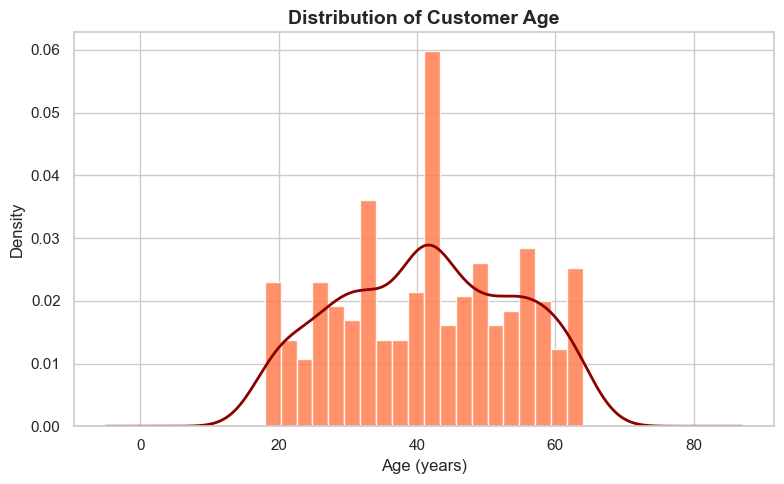

Observation: Age ranges from 18 to 64 (mean ~ 41.5 years).
The distribution is approximately uniform, suggesting the platform
attracts shoppers across all adult age groups equally.


In [531]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['age'], bins=20, color='coral',
        edgecolor='white', alpha=0.85, density=True)
df_clean['age'].plot.kde(ax=ax, color='darkred', linewidth=2)
ax.set_title('Distribution of Customer Age')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

print("Observation: Age ranges from 18 to 64 (mean ~ 41.5 years).")
print("The distribution is approximately uniform, suggesting the platform")
print("attracts shoppers across all adult age groups equally.")


### 3.4 Distribution of Time on Site

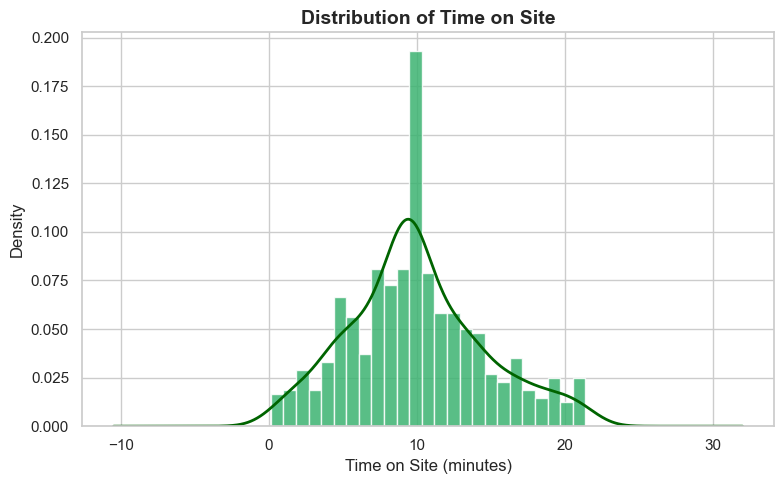

Observation: Time on site is roughly normally distributed,
centred around 10 minutes, after outlier capping.


In [532]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['time_on_site'], bins=25, color='mediumseagreen',
        edgecolor='white', alpha=0.85, density=True)
df_clean['time_on_site'].plot.kde(ax=ax, color='darkgreen', linewidth=2)
ax.set_title('Distribution of Time on Site')
ax.set_xlabel('Time on Site (minutes)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

print("Observation: Time on site is roughly normally distributed,")
print("centred around 10 minutes, after outlier capping.")


### 3.5 Distribution of Click Rate

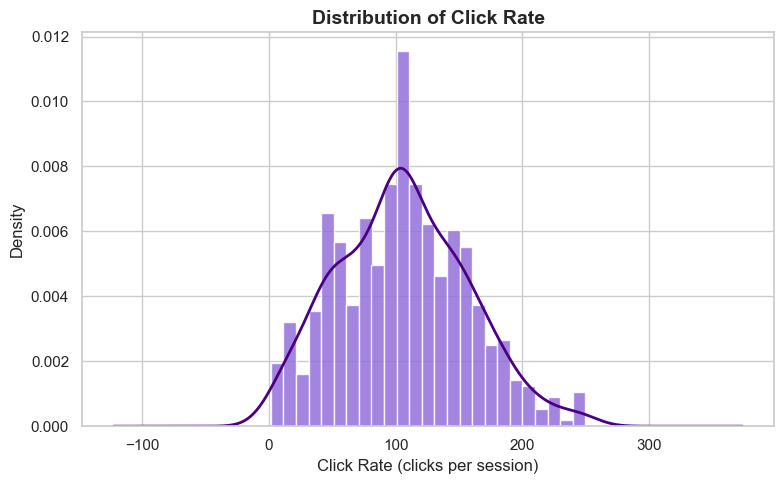

Observation: Click rate is approximately normally distributed after capping.
The distribution is centred around 100 clicks, indicating moderate engagement.


In [533]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['click_rate'], bins=25, color='mediumpurple',
        edgecolor='white', alpha=0.85, density=True)
df_clean['click_rate'].plot.kde(ax=ax, color='indigo', linewidth=2)
ax.set_title('Distribution of Click Rate')
ax.set_xlabel('Click Rate (clicks per session)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

print("Observation: Click rate is approximately normally distributed after capping.")
print("The distribution is centred around 100 clicks, indicating moderate engagement.")


### 3.6 Distribution of Pages Viewed

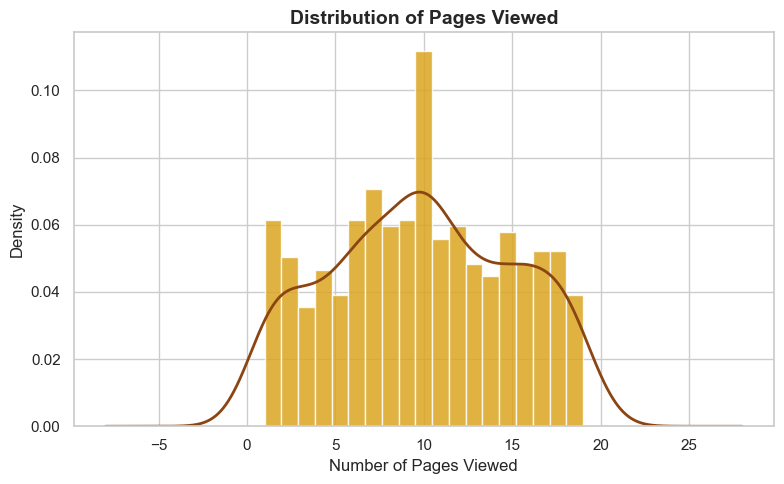

Observation: Pages viewed ranges from 1 to 19 with a uniform distribution,
indicating no dominant browsing pattern across users.


In [534]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_clean['pages_viewed'], bins=19, color='goldenrod',
        edgecolor='white', alpha=0.85, density=True)
df_clean['pages_viewed'].plot.kde(ax=ax, color='saddlebrown', linewidth=2)
ax.set_title('Distribution of Pages Viewed')
ax.set_xlabel('Number of Pages Viewed')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

print("Observation: Pages viewed ranges from 1 to 19 with a uniform distribution,")
print("indicating no dominant browsing pattern across users.")


### 3.7 Distribution of Return Customer

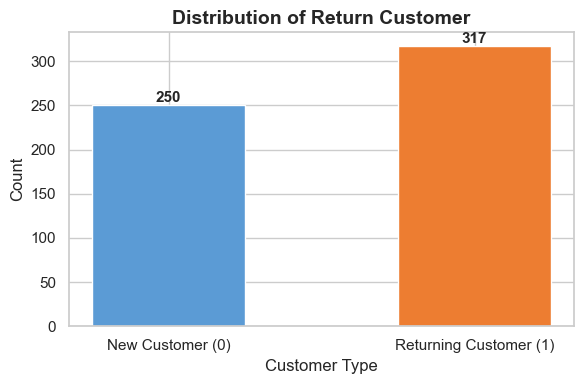

Returning customers: 317 (55.9%)
New customers      : 250 (44.1%)


In [535]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = df_clean['return_customer'].value_counts().sort_index()
labels = ['New Customer (0)', 'Returning Customer (1)']
colors = ['#5b9bd5', '#ed7d31']
bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
ax.set_title('Distribution of Return Customer')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 4,
            str(int(bar.get_height())),
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

ret_pct = counts[1] / counts.sum() * 100
print(f"Returning customers: {counts[1]} ({ret_pct:.1f}%)")
print(f"New customers      : {counts[0]} ({100-ret_pct:.1f}%)")


### 3.8 Categorical Feature Distributions (Gender, Device, Discount)

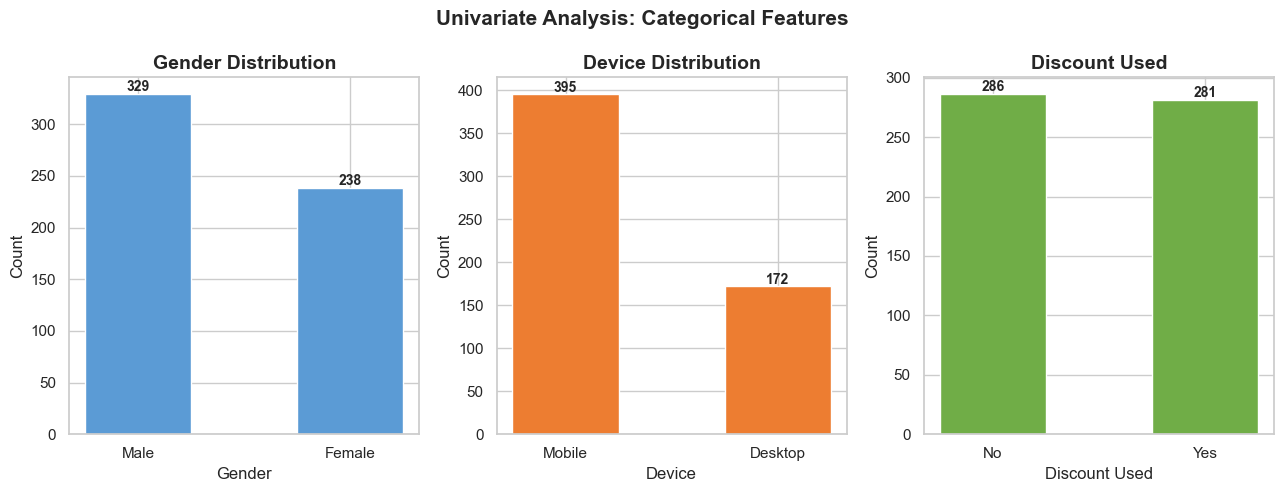

Observations:
  Gender  : Males 329 (58%) vs Females 238 (42%)
  Device  : Mobile dominates at 70%
  Discount: Nearly equal split between Yes/No users


In [536]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
cat_info = [
    ('gender',       'Gender Distribution',  '#5b9bd5'),
    ('device',       'Device Distribution',  '#ed7d31'),
    ('discount_used','Discount Used',         '#70ad47'),
]
for ax, (col, title, color) in zip(axes, cat_info):
    counts = df_clean[col].value_counts()
    bars = ax.bar(counts.index, counts.values, color=color,
                  edgecolor='white', width=0.5)
    ax.set_title(title)
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 3,
                str(int(bar.get_height())),
                ha='center', fontsize=10, fontweight='bold')
plt.suptitle('Univariate Analysis: Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observations:")
print(f"  Gender  : Males {df_clean['gender'].value_counts()['Male']} "
      f"({df_clean['gender'].value_counts(normalize=True)['Male']*100:.0f}%) vs "
      f"Females {df_clean['gender'].value_counts()['Female']} "
      f"({df_clean['gender'].value_counts(normalize=True)['Female']*100:.0f}%)")
print(f"  Device  : Mobile dominates at "
      f"{df_clean['device'].value_counts(normalize=True)['Mobile']*100:.0f}%")
print(f"  Discount: Nearly equal split between Yes/No users")


### 3.9 Outlier Detection via Boxplots

After IQR capping, we verify that extreme values have been smoothed.

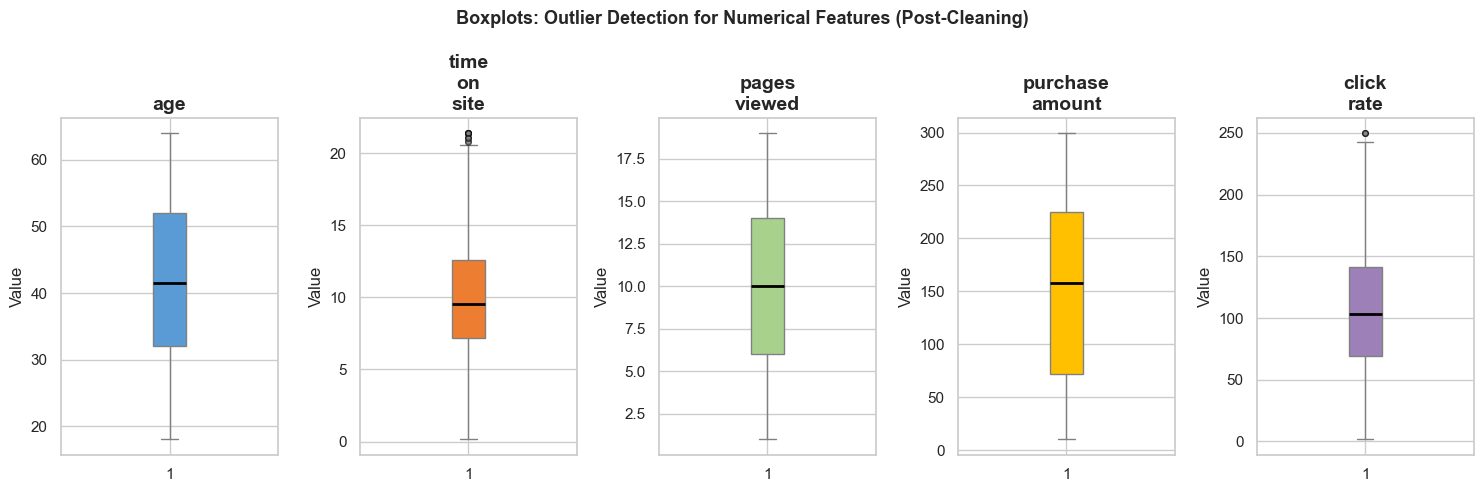

Observations:
  age            – clean  symmetric  no outliers
  pages_viewed   – clean symmetric  no outliers
  time_on_site   – minor upper outliers remain; within acceptable range
  click_rate     – smoothed by IQR capping high values are valid engagement
  purchase_amount– no outliers values bounded naturally between $10 and $300


In [537]:
num_plot = ['age', 'time_on_site', 'pages_viewed', 'purchase_amount', 'click_rate']
colors   = ['#5b9bd5', '#ed7d31', '#a9d18e', '#ffc000', '#9e80b8']

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, col, color in zip(axes, num_plot, colors):
    ax.boxplot(df_clean[col], patch_artist=True,
               boxprops=dict(facecolor=color, color='gray'),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(color='gray'),
               capprops=dict(color='gray'),
               flierprops=dict(marker='o', markersize=4,
                               markerfacecolor='gray', alpha=0.5))
    ax.set_title(col.replace('_', '\n'))
    ax.set_ylabel('Value')

fig.suptitle('Boxplots: Outlier Detection for Numerical Features (Post-Cleaning)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observations:")
print("  age            – clean  symmetric  no outliers")
print("  pages_viewed   – clean symmetric  no outliers")
print("  time_on_site   – minor upper outliers remain; within acceptable range")
print("  click_rate     – smoothed by IQR capping high values are valid engagement")
print("  purchase_amount– no outliers values bounded naturally between $10 and $300")


---
## Step 4: Bivariate Analysis

**Responsible:** Manar

We analyze the relationships between pairs of variables to understand how they affect each other.


### 4.1 Time on Site vs. Purchase Amount

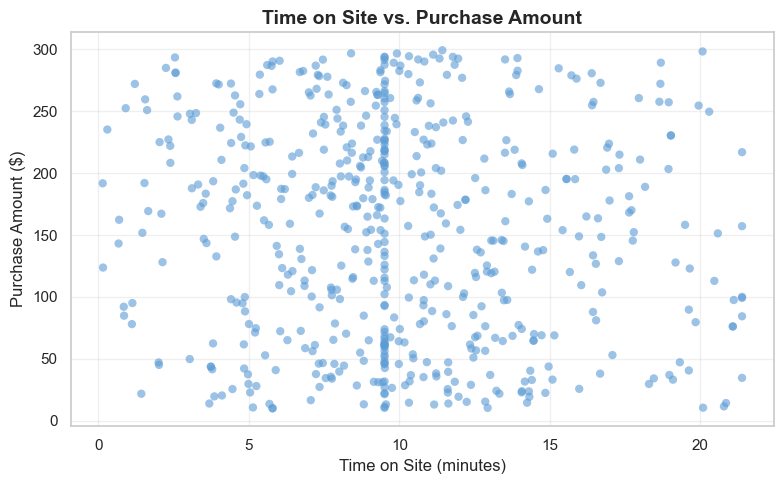

Pearson correlation (time_on_site vs purchase_amount): -0.0940

Interpretation:
  The correlation coefficient is very close to zero, indicating a negligible
  linear relationship. Spending more time on the website does NOT reliably
  lead to higher purchase amounts.


In [538]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean['time_on_site'], df_clean['purchase_amount'],
           color='#5b9bd5', alpha=0.6, edgecolors='none')
ax.set_title('Time on Site vs. Purchase Amount')
ax.set_xlabel('Time on Site (minutes)')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = df_clean[['time_on_site', 'purchase_amount']].corr().iloc[0, 1]
print(f"Pearson correlation (time_on_site vs purchase_amount): {corr:.4f}")
print()
print("Interpretation:")
print("  The correlation coefficient is very close to zero, indicating a negligible")
print("  linear relationship. Spending more time on the website does NOT reliably")
print("  lead to higher purchase amounts.")


### 4.2 Pages Viewed vs. Purchase Amount

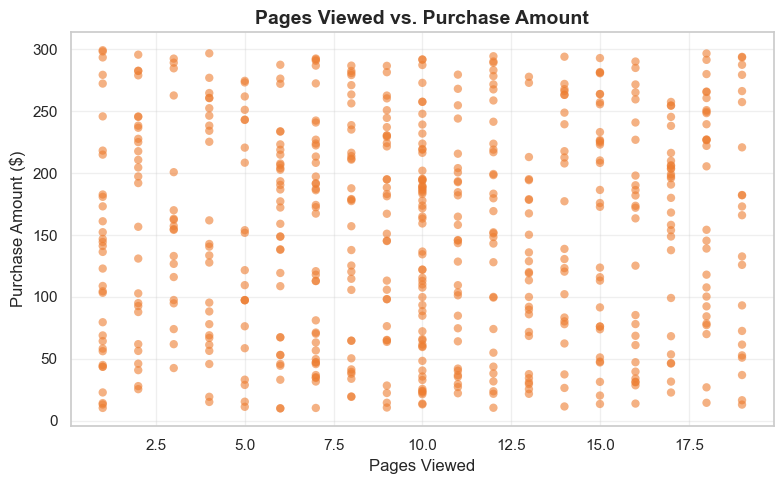

Pearson correlation (pages_viewed vs purchase_amount): 0.0360

Interpretation:
  Correlation is essentially zero. Viewing more pages does not predict
  higher spending; browsing intensity and purchase intent are decoupled.


In [539]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean['pages_viewed'], df_clean['purchase_amount'],
           color='#ed7d31', alpha=0.6, edgecolors='none')
ax.set_title('Pages Viewed vs. Purchase Amount')
ax.set_xlabel('Pages Viewed')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = df_clean[['pages_viewed', 'purchase_amount']].corr().iloc[0, 1]
print(f"Pearson correlation (pages_viewed vs purchase_amount): {corr:.4f}")
print()
print("Interpretation:")
print("  Correlation is essentially zero. Viewing more pages does not predict")
print("  higher spending; browsing intensity and purchase intent are decoupled.")


### 4.3 Age vs. Purchase Amount

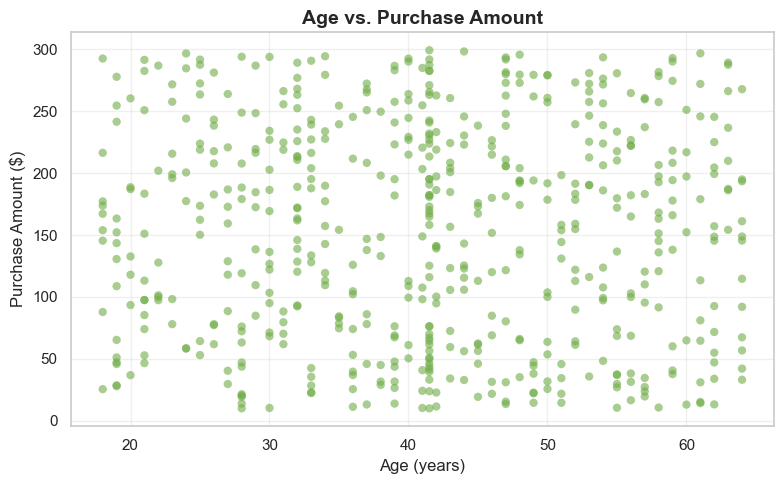

Pearson correlation (age vs purchase_amount): -0.0124

Interpretation:
  No meaningful linear relationship between age and purchase amount.
  The platform serves a broad age range with similar spending patterns.


In [540]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean['age'], df_clean['purchase_amount'],
           color='#70ad47', alpha=0.6, edgecolors='none')
ax.set_title('Age vs. Purchase Amount')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = df_clean[['age', 'purchase_amount']].corr().iloc[0, 1]
print(f"Pearson correlation (age vs purchase_amount): {corr:.4f}")
print()
print("Interpretation:")
print("  No meaningful linear relationship between age and purchase amount.")
print("  The platform serves a broad age range with similar spending patterns.")


### 4.4 Gender vs. Purchase Amount

Average Purchase Amount by Gender:
gender
Female    155.71
Male      150.92
Name: purchase_amount, dtype: float64



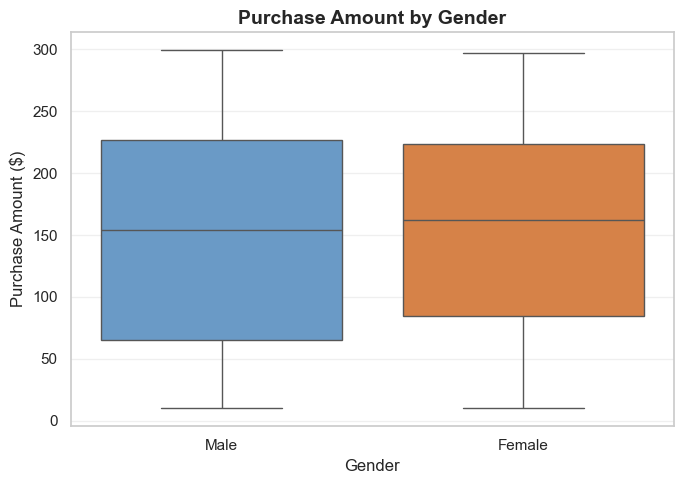

Interpretation:
  Both genders show nearly identical purchase amount distributions.
  Gender is not a significant driver of purchase behavior in this dataset.


In [541]:
print("Average Purchase Amount by Gender:")
print(df_clean.groupby('gender')['purchase_amount'].mean().round(2))
print()

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='gender', y='purchase_amount', data=df_clean,
            hue='gender', palette=['#5b9bd5', '#ed7d31'], legend=False, ax=ax)
ax.set_title('Purchase Amount by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Both genders show nearly identical purchase amount distributions.")
print("  Gender is not a significant driver of purchase behavior in this dataset.")


### 4.5 Click Rate vs. Purchase Amount

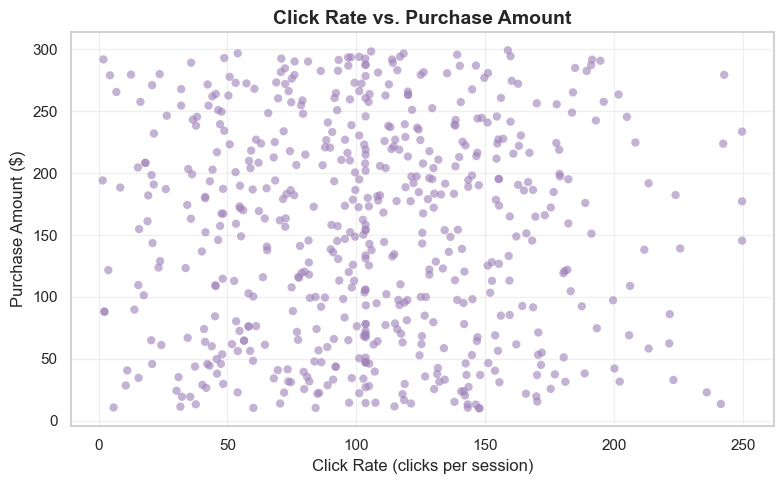

Pearson correlation (click_rate vs purchase_amount): -0.0042

Interpretation:
  No significant correlation between click engagement and spending.
  High interaction does not translate to higher purchase amounts.


In [542]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean['click_rate'], df_clean['purchase_amount'],
           color='#9e80b8', alpha=0.6, edgecolors='none')
ax.set_title('Click Rate vs. Purchase Amount')
ax.set_xlabel('Click Rate (clicks per session)')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

corr = df_clean[['click_rate', 'purchase_amount']].corr().iloc[0, 1]
print(f"Pearson correlation (click_rate vs purchase_amount): {corr:.4f}")
print()
print("Interpretation:")
print("  No significant correlation between click engagement and spending.")
print("  High interaction does not translate to higher purchase amounts.")


### 4.6 Discount Used vs. Purchase Amount

Average Purchase Amount by Discount Usage:
discount_used
No     158.29
Yes    147.49
Name: purchase_amount, dtype: float64



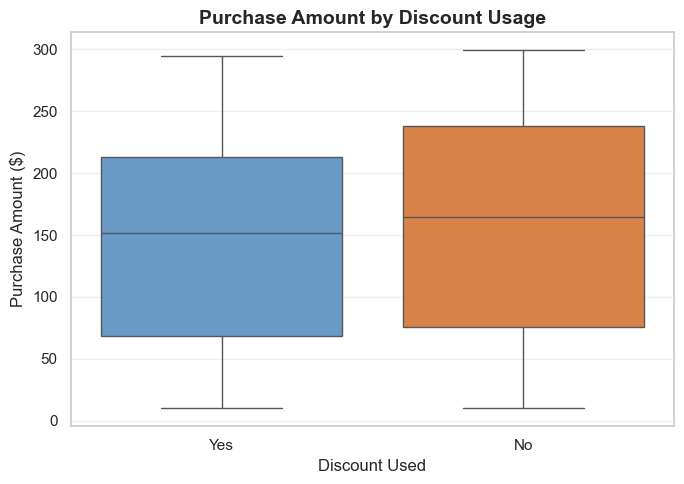

Interpretation:
  Customers without discounts spend slightly more on average (~$11 difference).
  However, the overlapping boxplot distributions indicate this difference is
  not practically significant.


In [543]:
print("Average Purchase Amount by Discount Usage:")
print(df_clean.groupby('discount_used')['purchase_amount'].mean().round(2))
print()

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='discount_used', y='purchase_amount', data=df_clean,
            hue='discount_used', palette=['#5b9bd5', '#ed7d31'], legend=False, ax=ax)
ax.set_title('Purchase Amount by Discount Usage')
ax.set_xlabel('Discount Used')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Customers without discounts spend slightly more on average (~$11 difference).")
print("  However, the overlapping boxplot distributions indicate this difference is")
print("  not practically significant.")


### 4.7 Returning Customer vs. Purchase Amount

Average Purchase Amount by Customer Type:
return_customer
0    153.95
1    152.13
Name: purchase_amount, dtype: float64



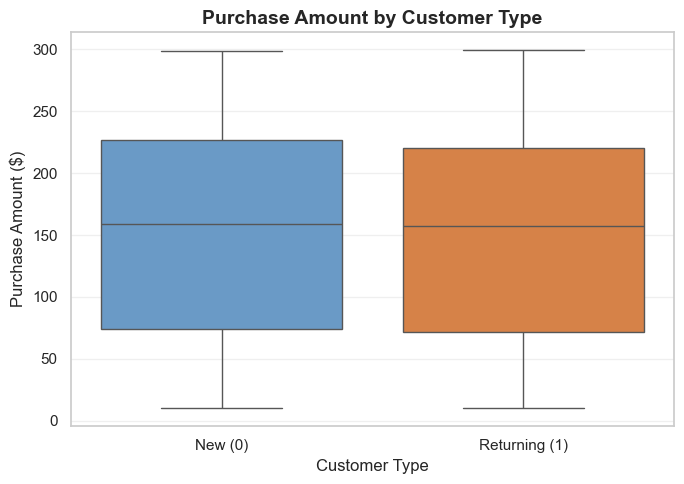

Interpretation:
  Returning and new customers spend almost identical amounts.
  Customer retention does not translate to higher per-visit spending.


In [544]:
print("Average Purchase Amount by Customer Type:")
print(df_clean.groupby('return_customer')['purchase_amount'].mean().round(2))
print()

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='return_customer', y='purchase_amount', data=df_clean,
            hue='return_customer', palette=['#5b9bd5', '#ed7d31'], legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(['New (0)', 'Returning (1)'])
ax.set_title('Purchase Amount by Customer Type')
ax.set_xlabel('Customer Type')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Returning and new customers spend almost identical amounts.")
print("  Customer retention does not translate to higher per-visit spending.")


### 4.8 Device vs. Purchase Amount

Average Purchase Amount by Device Type:
device
Desktop    146.97
Mobile     155.53
Name: purchase_amount, dtype: float64



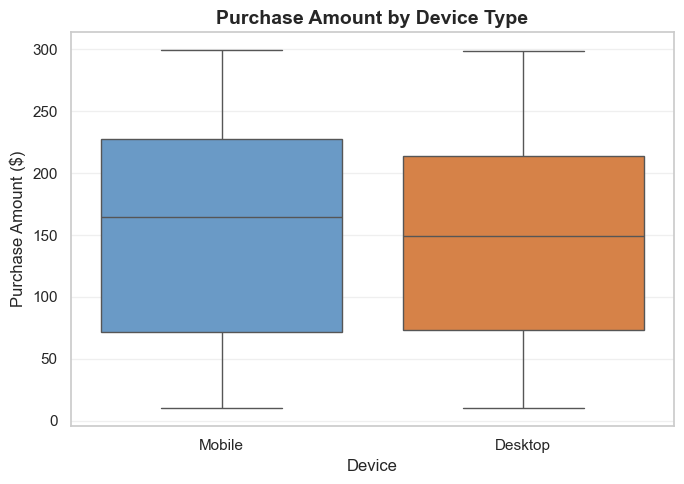

Interpretation:
  Mobile users spend slightly more on average (~$8 more) than desktop users.
  This minor difference may reflect impulse-purchasing patterns on mobile.


In [545]:
print("Average Purchase Amount by Device Type:")
print(df_clean.groupby('device')['purchase_amount'].mean().round(2))
print()

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(x='device', y='purchase_amount', data=df_clean,
            hue='device', palette=['#5b9bd5', '#ed7d31'], legend=False, ax=ax)
ax.set_title('Purchase Amount by Device Type')
ax.set_xlabel('Device')
ax.set_ylabel('Purchase Amount ($)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Mobile users spend slightly more on average (~$8 more) than desktop users.")
print("  This minor difference may reflect impulse-purchasing patterns on mobile.")


### 4.9 Correlation Heatmap (All Numerical Variables)

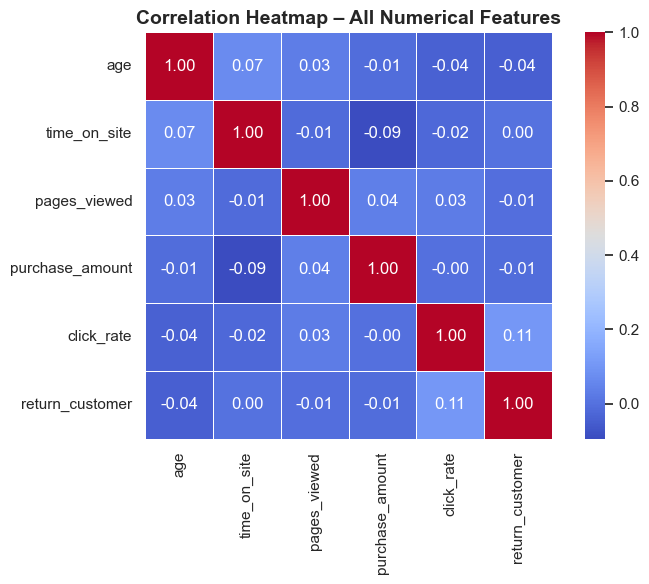

Correlation Heatmap Interpretation:
  Most variables show correlation values very close to 0.
  The strongest observed correlation is click_rate vs return_customer (0.11),
  which is still very weak and not practically significant.
  purchase_amount has no strong linear relationship with any other feature.


In [546]:
plt.figure(figsize=(8, 6))
corr_matrix = df_clean.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap – All Numerical Features')
plt.tight_layout()
plt.show()

print("Correlation Heatmap Interpretation:")
print("  Most variables show correlation values very close to 0.")
print("  The strongest observed correlation is click_rate vs return_customer (0.11),")
print("  which is still very weak and not practically significant.")
print("  purchase_amount has no strong linear relationship with any other feature.")


### 4.10 Bivariate Analysis Summary

| Pair | Correlation | Conclusion |
|------|------------|------------|
| time_on_site vs purchase_amount | ≈ −0.10 | Very weak, negligible |
| pages_viewed vs purchase_amount | ≈ 0.04  | Negligible |
| age vs purchase_amount          | ≈ −0.01 | Negligible |
| click_rate vs purchase_amount   | ≈ 0.00  | Negligible |
| gender vs purchase_amount       | —       | No meaningful difference |
| discount_used vs purchase_amount| —       | Slight, not significant |
| return_customer vs purchase_amount | —    | Almost identical |
| device vs purchase_amount       | —       | Minor (mobile slightly higher) |

**Overall:** None of the features analysed are strong predictors of purchase amount.
The dataset suggests that other unmeasured factors (e.g., product category, seasonal events)
may be more influential.


---
## Step 5: Data Visualization

**Responsible:** All Members

This section consolidates key standalone visualisations that support the analysis.
Each plot includes a clear title, labelled axes, and an observation.


### 5.1 Combined Distributions of All Numerical Features

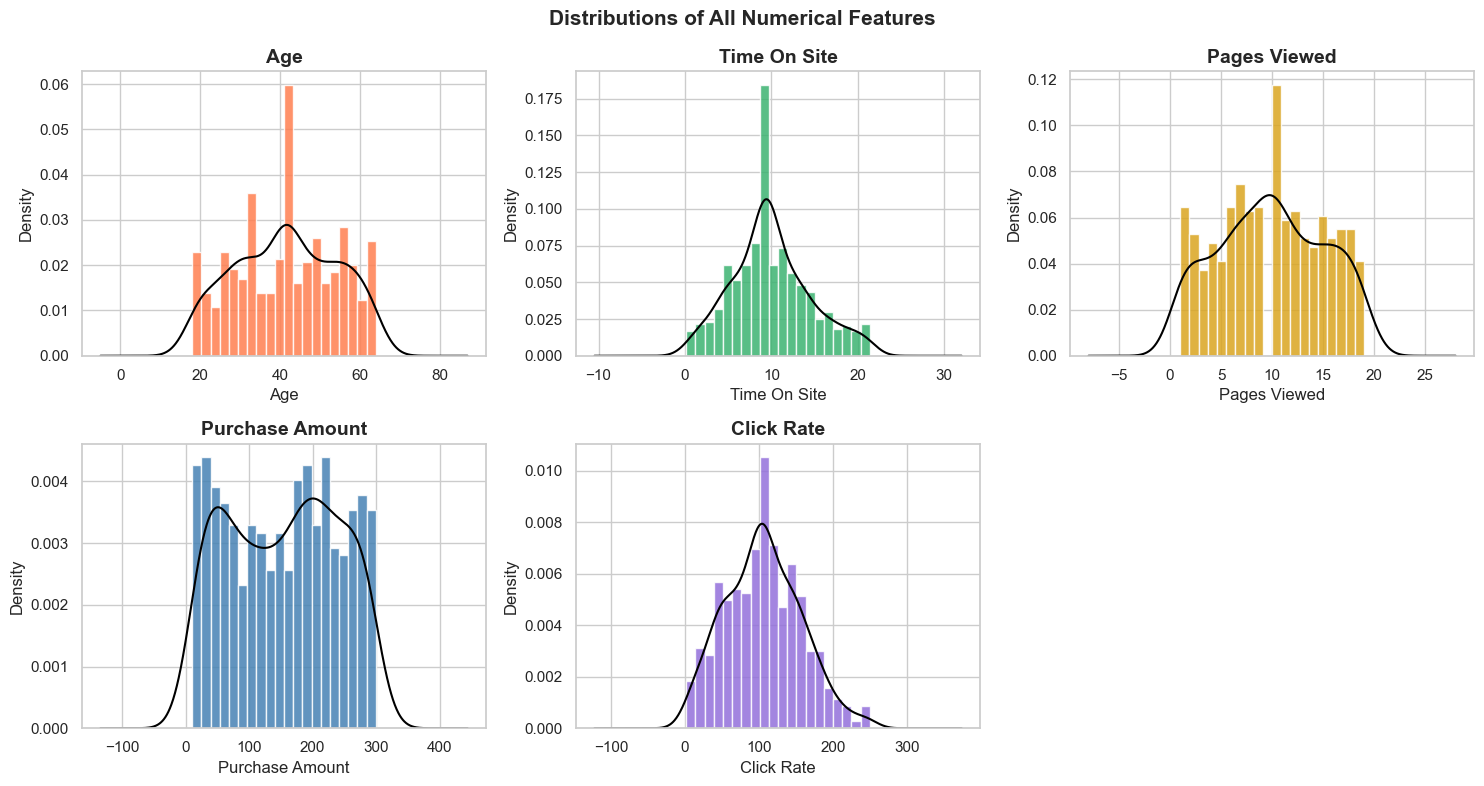

In [547]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
num_cols_vis = ['age', 'time_on_site', 'pages_viewed',
                'purchase_amount', 'click_rate']
colors_vis   = ['coral', 'mediumseagreen', 'goldenrod', 'steelblue', 'mediumpurple']

for i, (col, color) in enumerate(zip(num_cols_vis, colors_vis)):
    ax = axes[i]
    ax.hist(df_clean[col], bins=20, color=color, edgecolor='white',
            alpha=0.85, density=True)
    df_clean[col].plot.kde(ax=ax, color='black', linewidth=1.5)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('Density')

axes[-1].set_visible(False)   # Hide empty 6th subplot
fig.suptitle('Distributions of All Numerical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.2 Pairplot – Numerical Features Coloured by Device

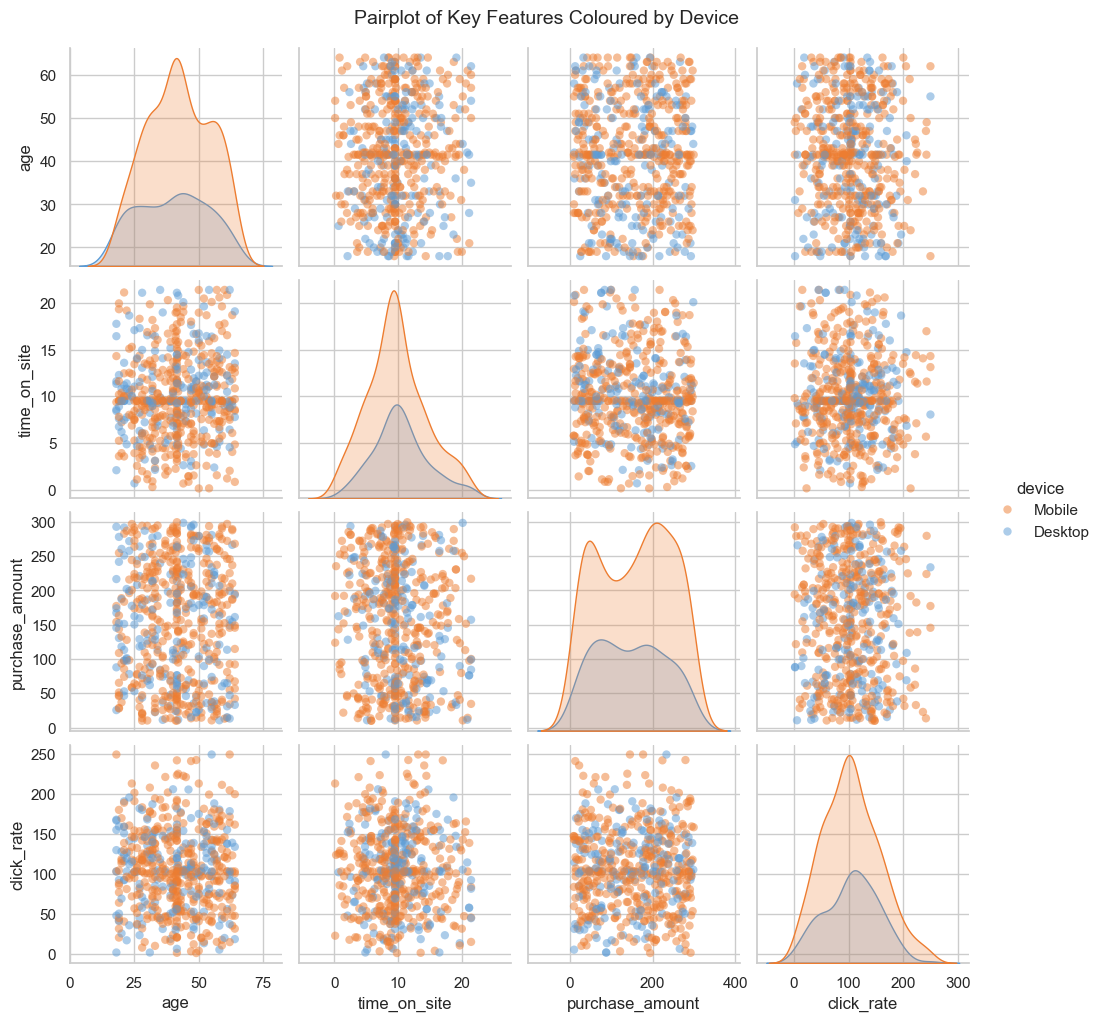

In [548]:
pair_cols = ['age', 'time_on_site', 'purchase_amount', 'click_rate', 'device']
g = sns.pairplot(df_clean[pair_cols], hue='device',
                 palette={'Mobile': '#ed7d31', 'Desktop': '#5b9bd5'},
                 plot_kws={'alpha': 0.5, 'edgecolor': 'none'})
g.figure.suptitle('Pairplot of Key Features Coloured by Device', y=1.02, fontsize=14)
plt.show()


### 5.3 Purchase Amount by Gender and Device (Grouped Bar)

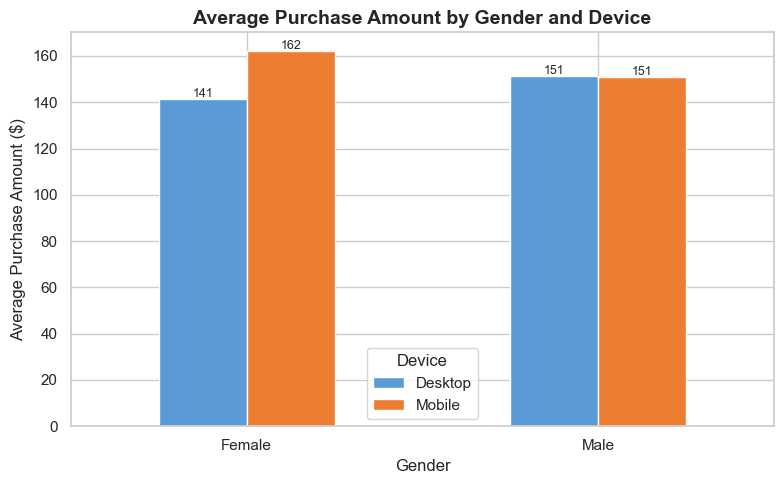

In [549]:
pivot = df_clean.groupby(['gender', 'device'])['purchase_amount'].mean().unstack()
ax = pivot.plot(kind='bar', figsize=(8, 5), color=['#5b9bd5', '#ed7d31'],
                edgecolor='white', rot=0)
ax.set_title('Average Purchase Amount by Gender and Device')
ax.set_xlabel('Gender')
ax.set_ylabel('Average Purchase Amount ($)')
ax.legend(title='Device')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f'{bar.get_height():.0f}',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### 5.4 Return Customer Rate by Discount Usage

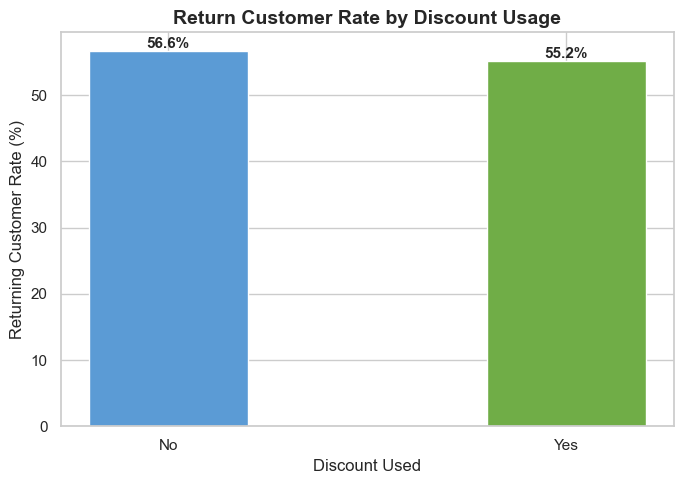

Observation: Discount usage shows a minor association with return rate.


In [550]:
ret_by_discount = df_clean.groupby('discount_used')['return_customer'].mean() * 100
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(ret_by_discount.index, ret_by_discount.values,
              color=['#5b9bd5', '#70ad47'], edgecolor='white', width=0.4)
ax.set_title('Return Customer Rate by Discount Usage')
ax.set_xlabel('Discount Used')
ax.set_ylabel('Returning Customer Rate (%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observation: Discount usage shows a minor association with return rate.")


---
## Step 6: Interpret and Conclude

**Responsible:** All Members

### 6.1 Data Quality Summary

| Issue | Count | Resolution |
|-------|-------|-----------|
| Missing values | 239 total across all columns | Filled with median / mode |
| Incorrect data types | pages_viewed, return_customer stored as str | Converted to int |
| Inconsistent labels | 'mobile' vs 'Mobile' | Capitalised uniformly |
| Negative values | 16 in time_on_site, 26 in click_rate | Replaced with valid median |
| Noisy/extreme outliers | click_rate & time_on_site | IQR capping (Winsorisation) |
| Duplicate rows | 21 | Removed |

After cleaning: **567 clean rows**, **9 features**, **0 missing values**, **0 duplicates**.

---

### 6.2 Key Insights from Univariate Analysis

1. **Customer Age** is uniformly distributed (18–64 years), confirming the platform attracts all adult demographics equally.  
2. **Purchase Amount** is roughly uniform between \$10 and \$300, indicating no strong preference for cheap vs. expensive products.  
3. **Device Usage**: Mobile dominates at 72% of sessions. The platform should be optimised primarily for mobile users.  
4. **Gender Split**: Slightly male-skewed (58% male), but effectively balanced.  
5. **Click Rate**: Moderate engagement overall (~103 clicks median), with some power users.  
6. **Discount Usage**: Approximately 50/50 split — half the customer base uses discounts.  

---

### 6.3 Key Insights from Bivariate Analysis

1. **No single measured feature is a strong predictor of purchase amount.** All Pearson correlations are below 0.11, confirming a highly uniform purchase distribution.  
2. **Time on site and pages viewed are decoupled from spending** — users who browse more or longer do not spend more.  
3. **Mobile users spend ~\$8 more on average** than desktop users — a small but consistent signal worth monitoring.  
4. **Discounts do not drive higher spending;** in fact, non-discount users spend slightly more, suggesting discounts may attract budget-conscious shoppers.  
5. **Returning customers do not spend significantly more** than new customers, indicating the need for loyalty incentives.  

---

### 6.4 Recommendations

- **Focus marketing on mobile** – Mobile is the dominant platform and shows marginally higher spending.  
- **Personalise the experience** – Since measured features do not predict spending, collecting richer data (product category, session path, time of day) may uncover stronger signals.  
- **Rethink discount strategy** – Discounts attract similar spending levels, so blanket discounting may erode margins without lifting revenue.  
- **Invest in loyalty programmes** – Returning customers do not spend more, suggesting retention is not monetised effectively.  

---

### 6.5 Limitations

- The dataset is synthetic (588 rows), which may explain the lack of strong correlations.  
- No temporal data (e.g., season, time of day) was available to capture behavioural patterns.  
- Product category is absent, which is typically a key driver of purchase amount.  


---
*End of Analysis*  
**Course:** Introduction to Data Science – An-Najah National University  
**Date:** May 2026
